# Titanic Survival Prediction — Exploratory Data Analysis

In this notebook we explore the Titanic dataset to understand its structure, distributions, relationships between features, and patterns that might help predict survival.

What you'll learn:

- How to load and inspect a dataset
- Identifying missing values
- Univariate and bivariate analysis
- Correlation analysis
- Visualizing survival patterns across different features

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv("dataset/titanic.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Overview

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Statistical summary of categorical columns
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 4. Missing Values Analysis

In [5]:
# Count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Key observations:

- Cabin has ~77% missing values — too many to impute reliably, we'll likely drop it
- Age has ~20% missing — we can impute using group medians
- Embarked has only 2 missing values — easy to fill with the mode

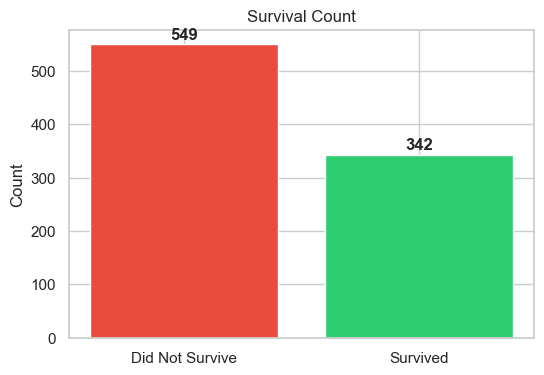

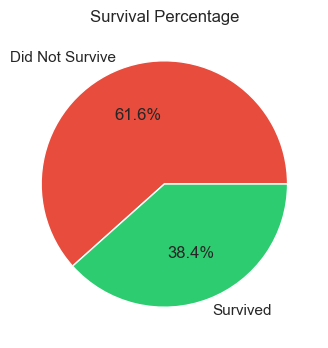


Survival rate: 38.38%
Death rate: 61.62%


In [6]:
# Survival distribution

# Bar chart
survived_counts = df["Survived"].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(["Did Not Survive", "Survived"], survived_counts.values, 
        color=["#e74c3c", "#2ecc71"])
plt.title("Survival Count")
plt.ylabel("Count")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(int(bar.get_height())), ha="center", fontweight="bold")
plt.show()

# Pie chart
plt.figure(figsize=(6, 4))
plt.pie(survived_counts.values, labels=["Did Not Survive", "Survived"],
        autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"])
plt.title("Survival Percentage")
plt.show()

print(f"\nSurvival rate: {df['Survived'].mean():.2%}")
print(f"Death rate: {1 - df['Survived'].mean():.2%}")

## 6. Univariate Analysis — Numerical Features

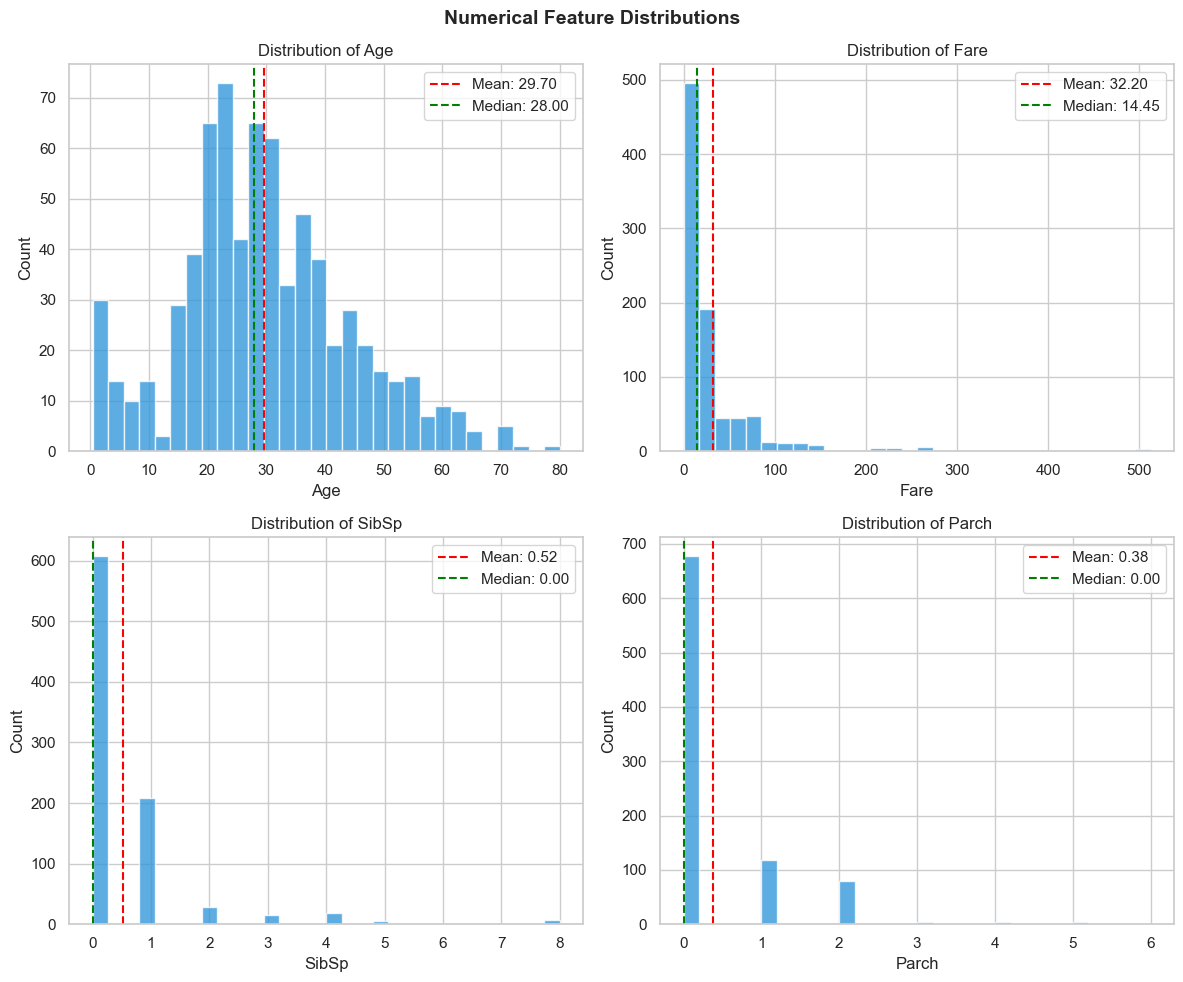

In [7]:
# Distribution of numerical features
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    plt.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    plt.axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

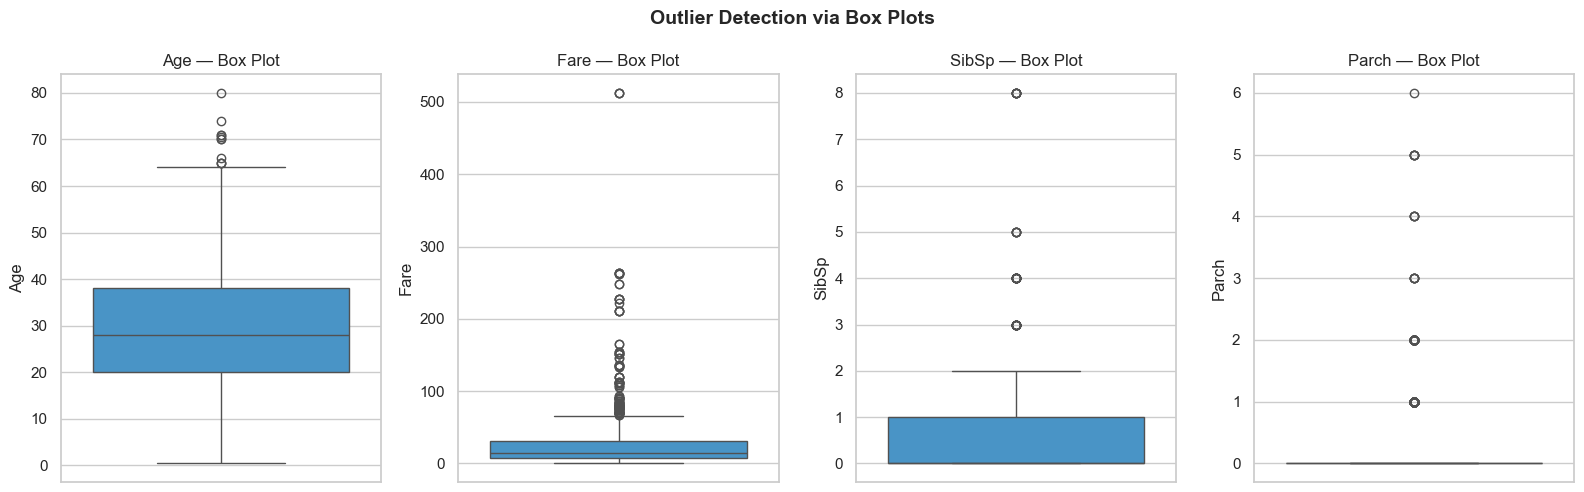

In [8]:
# Box plots to check for outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Observations:

- Age: roughly normally distributed, centered around ~30. Some outliers at high ages.
- Fare: heavily right-skewed with significant outliers. A few passengers paid very high fares.
- SibSp & Parch: most passengers traveled alone or with 1-2 family members.

## 7. Univariate Analysis — Categorical Features

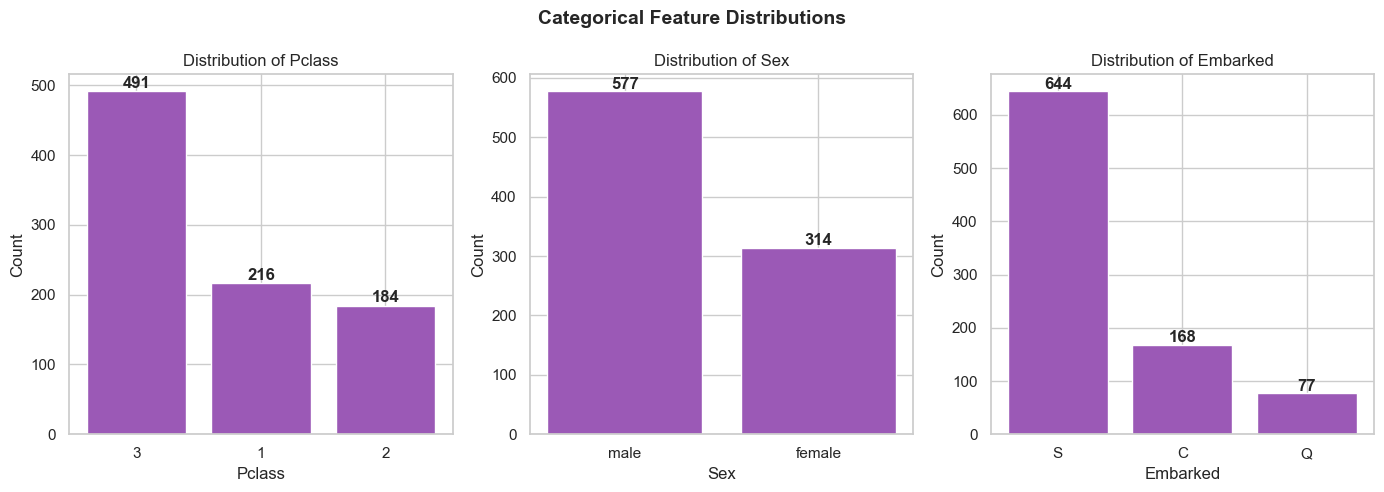

In [9]:
# Distribution of categorical features
categorical_cols = ["Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="#9b59b6", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis — Survival vs Features

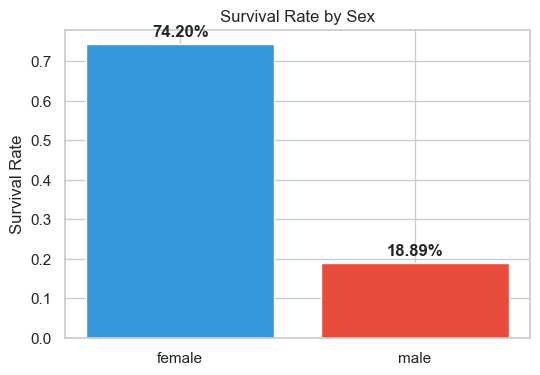

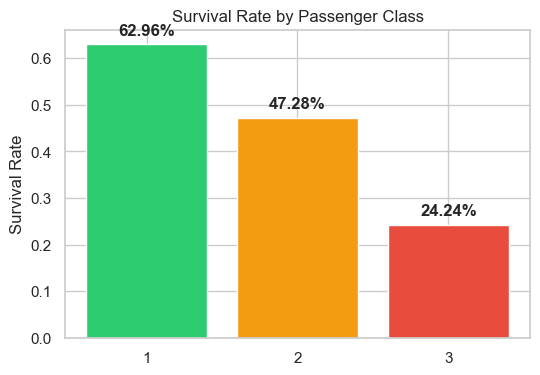

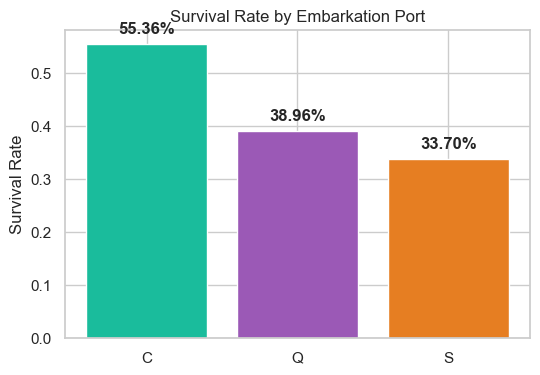

In [10]:
# Survival rate by Sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(6, 4))
plt.bar(survival_by_sex.index, survival_by_sex.values, color=["#3498db", "#e74c3c"])
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
for i, v in enumerate(survival_by_sex.values):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")
plt.show()

# Survival rate by Pclass
survival_by_class = df.groupby("Pclass")["Survived"].mean()
plt.figure(figsize=(6, 4))
plt.bar(survival_by_class.index.astype(str), survival_by_class.values,
        color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
for i, v in enumerate(survival_by_class.values):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")
plt.show()

# Survival rate by Embarked
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
plt.figure(figsize=(6, 4))
plt.bar(survival_by_embarked.index, survival_by_embarked.values,
        color=["#1abc9c", "#9b59b6", "#e67e22"])
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
for i, v in enumerate(survival_by_embarked.values):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")
plt.show()

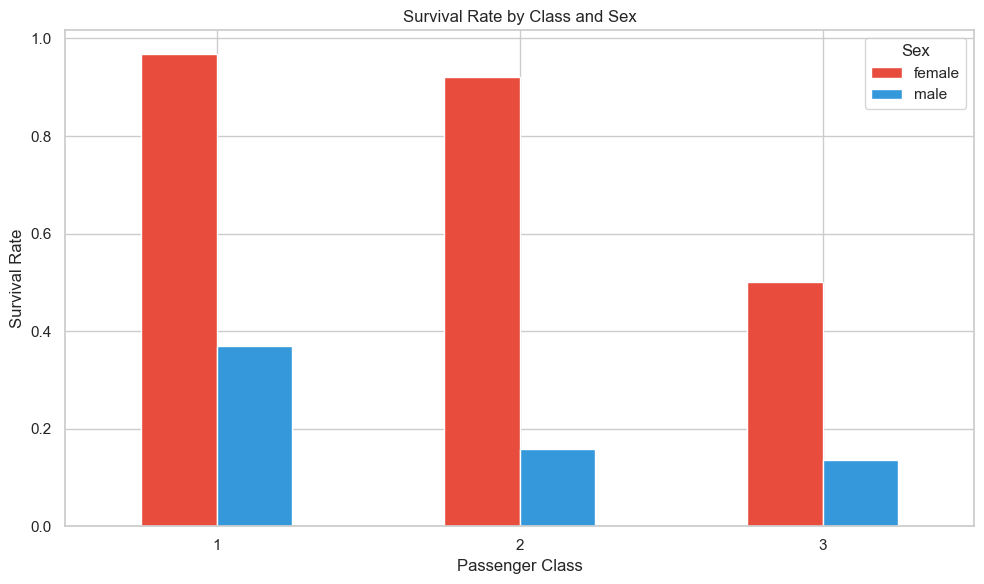

In [11]:
# Survival by Sex and Pclass combined
survival_grouped = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()

survival_grouped.plot(kind="bar", color=["#e74c3c", "#3498db"])
plt.title("Survival Rate by Class and Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

Key findings:

- Women had a much higher survival rate (~74%) compared to men (~19%) — "women and children first"
- 1st class passengers survived at a much higher rate (~63%) than 3rd class (~24%)
- Cherbourg passengers had the highest survival rate — likely because more 1st class passengers boarded there

## 9. Family Size Analysis

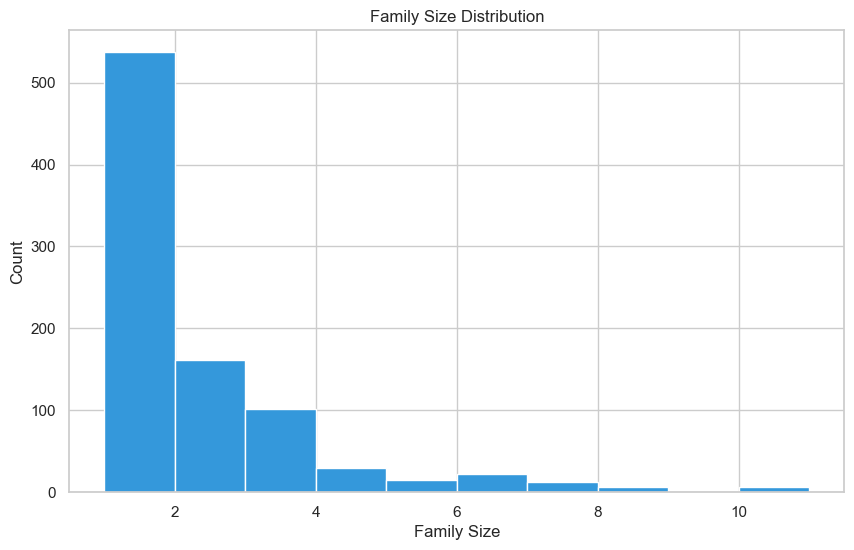

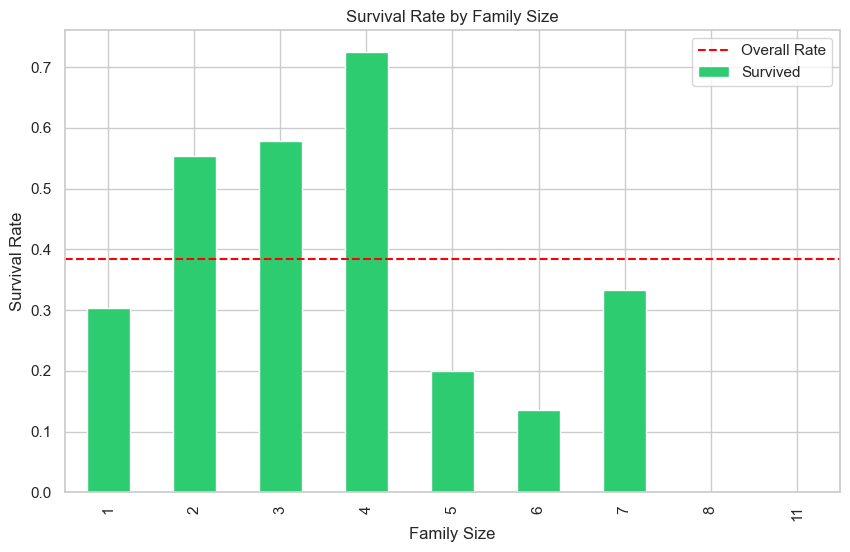

In [13]:
# Create FamilySize feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Distribution
df["FamilySize"].hist(bins=range(1, 12), color="#3498db", edgecolor="white")
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.show()

# Survival rate
df.groupby("FamilySize")["Survived"].mean().plot(kind="bar", color="#2ecc71")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.axhline(y=df["Survived"].mean(), color="red", linestyle="--", label="Overall Rate")
plt.legend()
plt.show()

## 10. Correlation Analysis

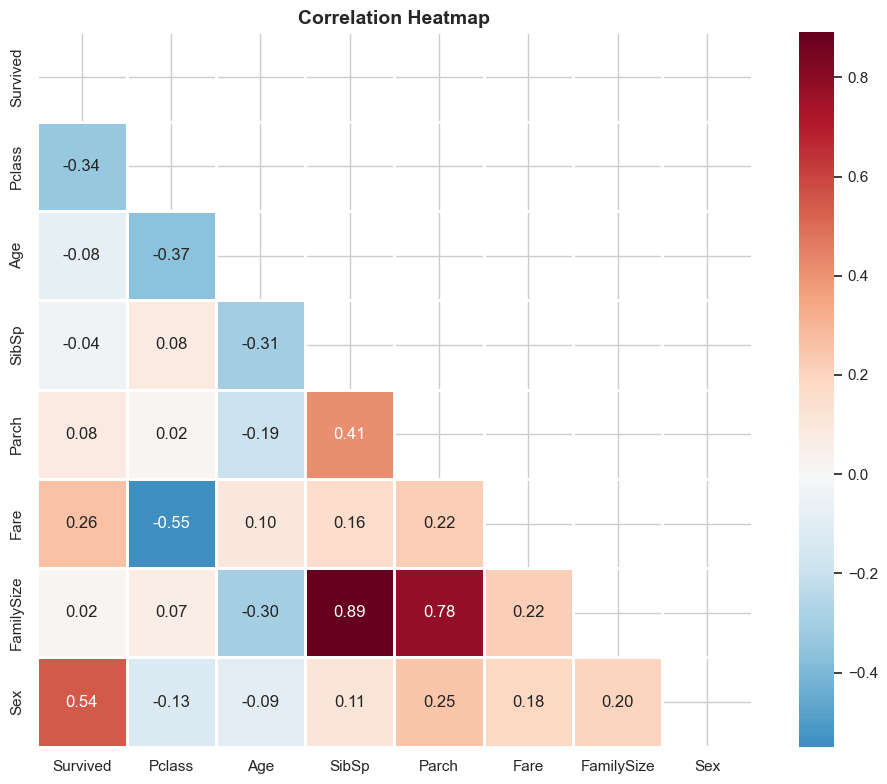

In [14]:
# Correlation heatmap of numerical features
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]].copy()
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()